In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
"""
This script shows how you can use the copernicusmarine library to obtain ocean data
that corresponds to an event. The process can be scaled up to match data to many
individual events to identify ocean conditions that correlate with an outcome of
interest.
"""
import copernicusmarine
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

copernicusmarine.login(
    username = "sng",
    password = "Copernicus1!",
)

INFO - 2026-09-18T22:26:11Z - Using existing credentials from C:\Users\syng8\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

In [3]:

# Define a hypothetical event we want to match data to
EVENT_NAME = "Chilean salmon mortality"
EVENT_DATE = datetime.strptime("2023-02-12", "%Y-%m-%d")
tolerance = timedelta(hours=12)
EVENT_LAT = -43.81
EVENT_LON = -73.66

In [4]:
###  Define data set to access ###
# This is the Copernicus Marine global ocean physics reanalysis
ds = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
)

# Select the variable, region, and date of interest. This stays lazy: nothing is
# downloaded until a compute step below forces it.
region = ds["thetao"].sel(
    longitude=slice(EVENT_LON-1.0, EVENT_LON+1.0),
    latitude=slice(EVENT_LAT-1.0, EVENT_LAT+1.0),
    time=EVENT_DATE,
    depth=slice(0,1.0)
)

INFO - 2026-09-18T22:26:15Z - Selected dataset version: "202311"
INFO - 2026-09-18T22:26:15Z - Selected dataset part: "default"


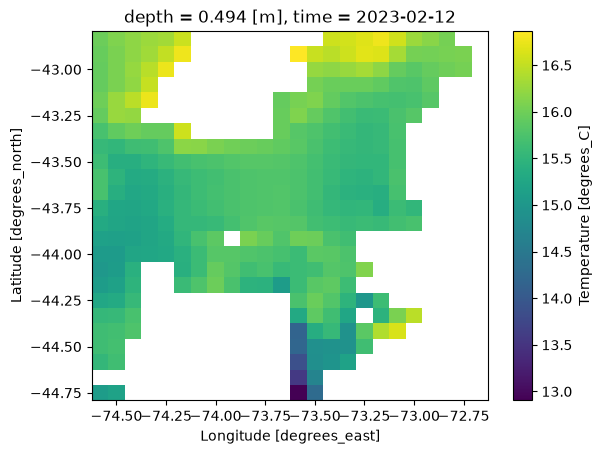

In [5]:
# Plot the data for the date of interest
region.plot(cmap='viridis')
plt.savefig("example_sst.png")

In [6]:
# Calculate statistics over the selected region and time
print("Average temperature",region.mean().compute().item())
print("99th percentile of temperature", region.quantile(0.99).compute().item())

Average temperature 15.70819964602312
99th percentile of temperature 16.757492603212594


In [7]:
# Format start and end dates to be Windows-friendly (no colons)
start_str = (EVENT_DATE - tolerance).strftime("%Y%m%d_%H%M")
end_str = (EVENT_DATE + tolerance).strftime("%Y%m%d_%H%M")

output_file = f"{EVENT_NAME}_{start_str}_{end_str}_sst.nc"
output_path = Path("copernicusmarine") / output_file

if output_path.exists():
    print("Data already loaded")
else:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
        variables=["thetao"],  # temperature
        minimum_longitude=EVENT_LON - 0.5,
        maximum_longitude=EVENT_LON + 0.5,
        minimum_latitude=EVENT_LAT - 0.5,
        maximum_latitude=EVENT_LAT + 0.5,
        start_datetime=EVENT_DATE - tolerance,
        end_datetime=EVENT_DATE + tolerance,
        minimum_depth=0,
        maximum_depth=1,  # extract surface conditions
        coordinates_selection_method="nearest",
        output_directory="copernicusmarine",
        output_filename=output_file,
    )

Data already loaded


<xarray.Dataset> Size: 3kB
Dimensions:    (time: 2, depth: 1, latitude: 13, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 16B 2023-02-12 2023-02-13
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 52B -44.33 -44.25 -44.17 ... -43.42 -43.33
  * longitude  (longitude) float32 52B -74.17 -74.08 -74.0 ... -73.25 -73.17
Data variables:
    thetao     (time, depth, latitude, longitude) float64 3kB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min

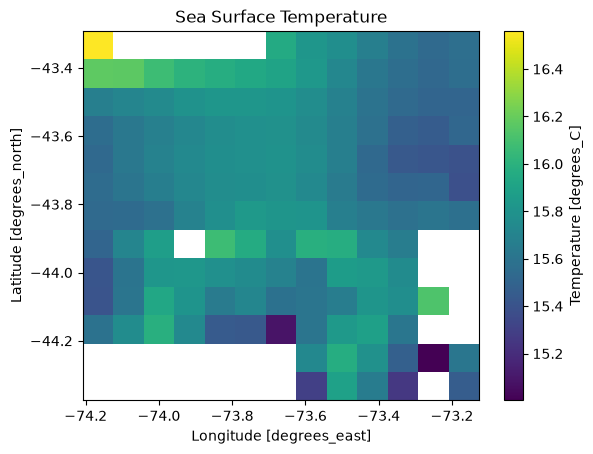

In [8]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Load the saved NetCDF file
file_path = Path("copernicusmarine") / output_file
ds = xr.open_dataset(file_path)

# Print summary to inspect dimensions and variables
print(ds)

# Plot sea surface temperature for the first time step
ds["thetao"].isel(time=0).plot(cmap='viridis')
plt.title("Sea Surface Temperature")
plt.show()